In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
!pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open

In [9]:
df = pd.read_excel('FINAL DATASET (BTP).xlsx')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

Shape: (131616, 8)

Columns: ['Date', 'Hour', 'Time Block', 'Purchase Bid (MW)', 'Sell Bid (MW)', 'MCV (MW)', 'Final Scheduled Volume (MW)', 'MCP (Rs/MWh) *']

Data Types:
 Date                           datetime64[ns]
Hour                                    int64
Time Block                             object
Purchase Bid (MW)                     float64
Sell Bid (MW)                         float64
MCV (MW)                              float64
Final Scheduled Volume (MW)           float64
MCP (Rs/MWh) *                        float64
dtype: object

Missing Values:
 Date                           0
Hour                           0
Time Block                     0
Purchase Bid (MW)              0
Sell Bid (MW)                  0
MCV (MW)                       0
Final Scheduled Volume (MW)    0
MCP (Rs/MWh) *                 0
dtype: int64

First 5 rows:
         Date  Hour     Time Block  Purchase Bid (MW)  Sell Bid (MW)  MCV (MW)  \
0 2022-04-01     1  00:00 - 00:15            17593.1 

In [10]:
df.columns = ['Date', 'Hour', 'TimeBlock', 'PurchaseBid', 'SellBid', 'MCV', 'FSV', 'MCP']
print("Renamed columns:", df.columns.tolist())

Renamed columns: ['Date', 'Hour', 'TimeBlock', 'PurchaseBid', 'SellBid', 'MCV', 'FSV', 'MCP']


In [11]:
df['Date']      = pd.to_datetime(df['Date'])
df['DayOfWeek'] = df['Date'].dt.dayofweek       # 0=Monday, 6=Sunday
df['Month']     = df['Date'].dt.month
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['IsPeakHour'] = df['Hour'].isin([7,8,9,10,18,19,20,21]).astype(int)

print(df[['Date','Hour','DayOfWeek','Month','IsWeekend','IsPeakHour']].head(10))

        Date  Hour  DayOfWeek  Month  IsWeekend  IsPeakHour
0 2022-04-01     1          4      4          0           0
1 2022-04-01     1          4      4          0           0
2 2022-04-01     1          4      4          0           0
3 2022-04-01     1          4      4          0           0
4 2022-04-01     2          4      4          0           0
5 2022-04-01     2          4      4          0           0
6 2022-04-01     2          4      4          0           0
7 2022-04-01     2          4      4          0           0
8 2022-04-01     3          4      4          0           0
9 2022-04-01     3          4      4          0           0


In [12]:
df_hourly = df.groupby(['Date', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsPeakHour']).agg(
    PurchaseBid = ('PurchaseBid', 'mean'),
    SellBid     = ('SellBid',     'mean'),
    MCV         = ('MCV',         'mean'),
    FSV         = ('FSV',         'mean'),
    MCP         = ('MCP',         'mean')
).reset_index()

df_hourly = df_hourly.sort_values(['Date', 'Hour']).reset_index(drop=True)

print("Hourly shape:", df_hourly.shape)
print(df_hourly.head())

Hourly shape: (32904, 11)
        Date  Hour  DayOfWeek  Month  IsWeekend  IsPeakHour  PurchaseBid  \
0 2022-04-01     1          4      4          0           0    17584.475   
1 2022-04-01     2          4      4          0           0    16467.975   
2 2022-04-01     3          4      4          0           0    15101.125   
3 2022-04-01     4          4      4          0           0    14200.725   
4 2022-04-01     5          4      4          0           0    13898.475   

    SellBid       MCV       FSV         MCP  
0  7794.500  7794.495  7794.495  20000.0000  
1  7723.725  7718.725  7718.725  19709.0550  
2  7729.725  7632.225  7632.225  16825.0275  
3  8013.200  7493.200  7493.200  11605.1950  
4  8031.375  7117.855  7117.855   8977.5225  


In [13]:
# Lag MCP by 1, 24, and 168 hours (short-run, daily, weekly periodicity)
df_hourly['MCP_lag1']   = df_hourly['MCP'].shift(1)    # previous hour
df_hourly['MCP_lag24']  = df_hourly['MCP'].shift(24)   # same hour yesterday
df_hourly['MCP_lag168'] = df_hourly['MCP'].shift(168)  # same hour last week

# Lag market features by 1 hour
df_hourly['PurchaseBid_lag1'] = df_hourly['PurchaseBid'].shift(1)
df_hourly['SellBid_lag1']     = df_hourly['SellBid'].shift(1)
df_hourly['MCV_lag1']         = df_hourly['MCV'].shift(1)

# Drop rows where lags are NaN (first 168 rows)
df_hourly.dropna(inplace=True)
df_hourly.reset_index(drop=True, inplace=True)

print("Shape after lag features:", df_hourly.shape)
print(df_hourly.head())

Shape after lag features: (32736, 17)
        Date  Hour  DayOfWeek  Month  IsWeekend  IsPeakHour  PurchaseBid  \
0 2022-04-08     1          4      4          0           0    17868.950   
1 2022-04-08     2          4      4          0           0    17113.625   
2 2022-04-08     3          4      4          0           0    15484.625   
3 2022-04-08     4          4      4          0           0    15898.500   
4 2022-04-08     5          4      4          0           0    16064.125   

    SellBid        MCV       FSV      MCP   MCP_lag1   MCP_lag24  MCP_lag168  \
0  6215.925  6110.9225  6110.925  12000.0  11975.155  12000.0000  20000.0000   
1  6219.175  6114.1750  6114.175  12000.0  12000.000  12000.0000  19709.0550   
2  6543.775  6438.7750  6438.775  12000.0  12000.000  12000.0000  16825.0275   
3  6522.675  6417.6750  6417.675  12000.0  12000.000  10485.5225  11605.1950   
4  6966.400  6861.4000  6861.400  12000.0  12000.000  10355.8950   8977.5225   

   PurchaseBid_lag1  Sel

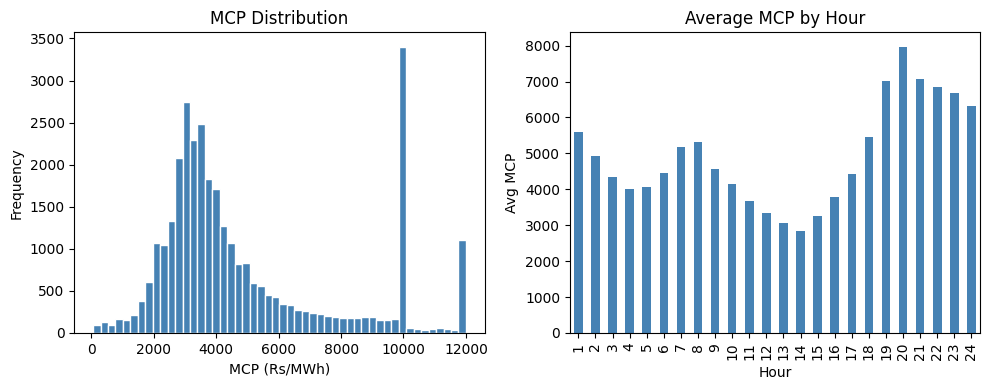

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_hourly['MCP'], bins=50, color='steelblue', edgecolor='white')
plt.title('MCP Distribution')
plt.xlabel('MCP (Rs/MWh)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df_hourly.groupby('Hour')['MCP'].mean().plot(kind='bar', color='steelblue')
plt.title('Average MCP by Hour')
plt.xlabel('Hour')
plt.ylabel('Avg MCP')

plt.tight_layout()
plt.show()

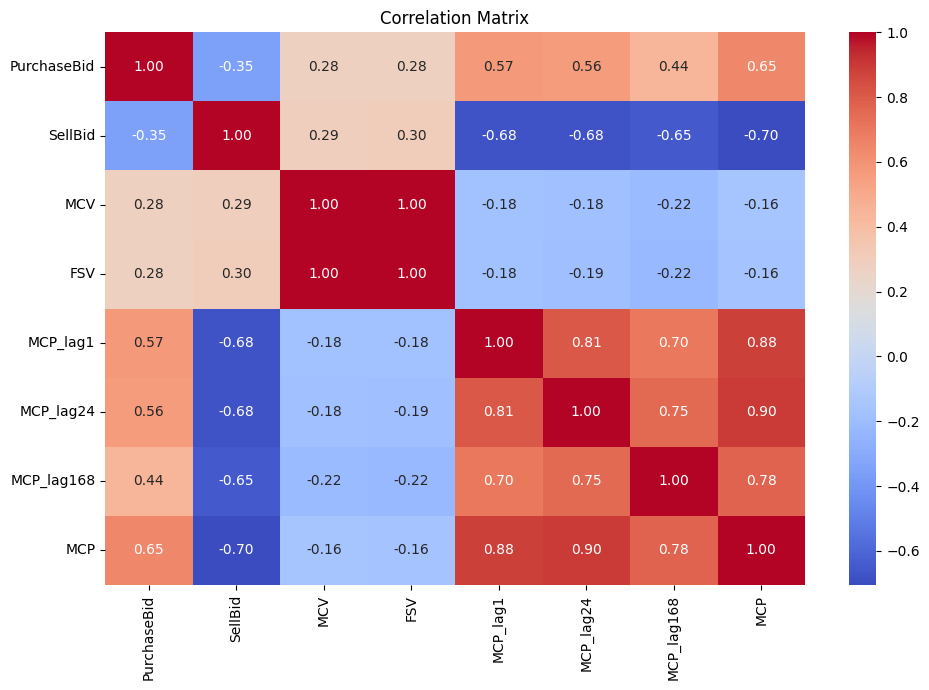

In [15]:
features = ['PurchaseBid', 'SellBid', 'MCV', 'FSV',
            'MCP_lag1', 'MCP_lag24', 'MCP_lag168', 'MCP']

plt.figure(figsize=(10, 7))
sns.heatmap(df_hourly[features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [16]:
df_hourly.to_csv('data_cleaned.csv', index=False)
print("Saved! Shape:", df_hourly.shape)
print("\nFinal columns:", df_hourly.columns.tolist())

Saved! Shape: (32736, 17)

Final columns: ['Date', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsPeakHour', 'PurchaseBid', 'SellBid', 'MCV', 'FSV', 'MCP', 'MCP_lag1', 'MCP_lag24', 'MCP_lag168', 'PurchaseBid_lag1', 'SellBid_lag1', 'MCV_lag1']
